In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import os
from io import StringIO


# Boxplot of overall total bits sent at each (overall) from the producer

# Boxplot for overall total bits sent at each configuration on the client for each config

# What percentage of time is the video at the preferred resolution? (bar chart with error bars for each layer)
# Boxplot for jitter for each layer in terms of consumer
# Boxplot for frames missed for each layer in terms of consumer

# Average bitrate throughout the video (for producer)
# Average bitrate throughout the video per layer (for consumer)

class FileInfo:
    def __init__(self, file_name: str) -> None:
        info = file_name[:-4].split('-')
        self.invalid = len(info) != 6
        if not self.invalid:
            self.id = info[0]
            self.system = info[1]
            self.codec = info[2]
            self.enc_type = info[3]
            self.spatial = int(info[4])
            self.temporal = int(info[5])

    def is_producer(self) -> bool:
        return self.system == "producer"

    def is_consumer(self) -> bool:
        return self.system == "consumer"

    def label(self, df: pd.DataFrame):
        df["codec"] = pd.Series((self.codec for _ in range(len(df.index))))
        df["enc_type"] = pd.Series((self.enc_type for _ in range(len(df.index))))

        if self.is_consumer():
            df["spatial"] = pd.Series((self.spatial for _ in range(len(df.index))))
            df["temporal"] = pd.Series((self.temporal for _ in range(len(df.index))))

    def label_row(self, r: pd.Series):
        r["testNum"] = self.id
        r["codec"] = self.codec
        r["enc_type"] = self.enc_type

        if self.is_consumer():
            r["spatial"] = self.spatial
            r["temporal"] = self.temporal


def expectedHeight(layer: int) -> int:
    match layer:
        case 0:
            return 270
        case 1:
            return 540
        case 2:
            return 1080
    raise Exception(f"Unknown spatial layer '{layer}'")


def expectedFrameRate(layer: int) -> float:
    match layer:
        case 0:
            return 7.5
        case 1:
            return 15
        case 2:
            return 30
    raise Exception(f"Unknown temporal layer '{layer}'")


DIR="single_machine"

In [3]:

from typing import Optional


def cache_data(data_dir: str):
    producer_total_bits = []
    consumer_total_bits = []

    all_consumer = []
    all_producer = []

    for file in os.scandir(data_dir):
        print(data_dir, "/", file.name)
        info = FileInfo(file.name)

        if info.invalid:
            continue

        with open(file.path) as f:
            tables = f.read().split("\n\n")
            producer, consumer, transport, size = tables

        transport = pd.read_csv(StringIO(transport))
        size = pd.read_csv(StringIO(size))

        totals = transport.iloc[-1][["bytesSent", "bytesReceived"]]
        info.label_row(totals)

        if info.is_producer():
            producer = pd.read_csv(StringIO(producer))

            totals_cols = ["totalPacketSendDelay", "totalEncodeTime", "totalEncodedBytesTarget", "retransmittedBytesSent", "retransmittedPacketsSent", "framesEncoded", "framesSent", "headerBytesSent", "hugeFramesSent", "keyFramesEncoded", "pliCount", "nackCount"]
            if info.enc_type == "svc":
                totals = pd.concat([totals, producer.iloc[-1][totals_cols]])
            else:
                # Simulcast does 3 streams separately
                totals = pd.concat([totals, producer.iloc[-1][totals_cols] + producer.iloc[-2][totals_cols] + producer.iloc[-2][totals_cols]])
            producer_total_bits.append(totals)

            to_extract = ["timestamp", "bytesSent", "packetsSent", "framesEncoded", "framesSent", "hugeFramesSent"]
            start_time = None
            for i in range(0, len(producer) - 5, 3):
                before = producer.iloc[i] + producer.iloc[i + 1] + producer.iloc[i + 2]
                after = producer.iloc[i + 3] + producer.iloc[i + 3 + 1] + producer.iloc[i + 3 + 2]
                diff = after[to_extract] - before[to_extract]

                if diff["timestamp"] == 0:
                    continue

                if start_time is None:
                    start_time = before["timestamp"]

                info.label_row(diff)
                diff["time"] = diff["timestamp"]
                diff["timestamp"] = after["timestamp"] - start_time

                all_producer.append(diff)
        else:
            consumer = pd.read_csv(StringIO(consumer))

            frozen_ranges = []
            previous_frozen_dur = 0
            # Frozen duration is added all in one go after the frozen stat has been incremented
            for r in consumer.iloc:
                if r["totalFreezesDuration"] != previous_frozen_dur:
                    # totalFreezesDuration is in seconds whereas timestamp is in milliseconds
                    diff = (r["totalFreezesDuration"] - previous_frozen_dur) * 1000
                    frozen_ranges.append((r["timestamp"] - diff, r["timestamp"]))
                    previous_frozen_dur = r["totalFreezesDuration"]

            # Definitely could be optimised but who has time for that?
            # stream_is_frozen = lambda t: any((t in r for r in frozen_ranges))
            def stream_is_frozen(start: float, end: float) -> float:
                overlap = 0.0

                for r in frozen_ranges:
                    if r[0] > end:
                        # No point exploring further (as all ranges will be above our search grid)
                        break
                    elif r[1] < start:
                        # This range is too small, can move onto the next
                        continue

                    # We know that there is an overlap in some way
                    if start > r[0]:
                        overlap += min(r[1], end) - start
                    elif end < r[1]:
                        overlap += end - max(r[0], start)
                    else:
                        # We are straddling the frozen time
                        overlap += r[1] - r[0]

                return overlap

            def onPreferredLayer(row: pd.Series) -> bool:
                return row["height"] >= expectedHeight(info.spatial) and row["framerate"] > expectedFrameRate(info.temporal) - 1

            total_time = 0.0
            correct_time = 0.0
            frozen_correction = 0.0
            for i in range(len(size) - 1):
                before = size.iloc[i]
                after = size.iloc[i + 1]
                if after["framerate"] == "" or before["framerate"] == "":
                    continue

                frozen_length = stream_is_frozen(before["timestamp"], after["timestamp"])

                time_diff = after["timestamp"] - before["timestamp"]
                total_time += time_diff

                afterOnPreferred = onPreferredLayer(after)
                beforeOnPreferred = onPreferredLayer(before)
                if afterOnPreferred and beforeOnPreferred:
                    correct_time += time_diff - frozen_length
                    frozen_correction += frozen_length
                elif afterOnPreferred and frozen_length == 0.0:
                    correct_time += time_diff
                # If the frozen length is not zero, we assume that the whole time spent at the current max resolution was frozen

            totals["recordedTime"] = total_time
            totals["atCorrectResTime"] = correct_time
            totals["correctResPerc"] = (correct_time / total_time) * 100
            totals["correctedFromFrozen"] = frozen_correction

            totals_cols = ["jitterBufferDelay", "totalAssemblyTime", "totalDecodeTime", "totalFreezesDuration", "totalInterFrameDelay", "totalSquaredInterFrameDelay", "totalPausesDuration", "totalProcessingDelay", "framesDecoded", "framesDropped", "framesReceived", "freezeCount"]
            # Simulcast gets merged into one stream
            totals = pd.concat([totals, consumer.iloc[-1][totals_cols]])
            consumer_total_bits.append(totals)

            has_height = True
            try:
                consumer["frameHeight"]
            except:
                print("No FrameHeight")
                has_height = False

            # 270 | 540 | 1080
            to_extract = ["timestamp", "bytesReceived", "framesDecoded", "framesDropped", "framesReceived", "totalFreezesDuration", "freezeCount"]
            additional = ["jitter"]
            start_time = None
            for i in range(len(consumer) - 1):
                before = consumer.iloc[i]
                after = consumer.iloc[i + 1]

                diff = after[to_extract] - before[to_extract]

                if diff["timestamp"] == 0:
                    continue

                if start_time is None:
                    start_time = before["timestamp"]

                info.label_row(diff)
                diff["time"] = diff["timestamp"]
                diff["timestamp"] = after["timestamp"] - start_time

                diff["frozenFor"] = stream_is_frozen(before["timestamp"], after["timestamp"])

                if has_height:
                    diff["atExpectedRes"] = 1 if after["frameHeight"] == expectedHeight(info.spatial) else 0

                diff = pd.concat([diff, before[additional]])

                all_consumer.append(diff)

    all_consumer = pd.DataFrame(all_consumer)
    all_producer = pd.DataFrame(all_producer)

    producer_total_bits = pd.DataFrame(producer_total_bits)
    consumer_total_bits = pd.DataFrame(consumer_total_bits)

    dir = Path(data_dir)

    all_consumer.to_csv(dir.joinpath("all_consumer.csv"))
    all_producer.to_csv(dir.joinpath("all_producer.csv"))

    producer_total_bits.to_csv(dir.joinpath("producer_total_bits.csv"))
    consumer_total_bits.to_csv(dir.joinpath("consumer_total_bits.csv"))

    return all_consumer, all_producer, producer_total_bits, consumer_total_bits

cache_data("phone")
cache_data("single_machine")
cache_data("two_machine")
cache_data("single_no_enc")

phone / 0-producer-video_av1-svc-0-0.csv
phone / 1-producer-video_av1-svc-0-1.csv
phone / 10-producer-video_av1-simulcast-0-1.csv
phone / 100-producer-video_vp9-simulcast-0-1.csv
phone / 101-producer-video_vp9-simulcast-0-2.csv
phone / 102-producer-video_vp9-simulcast-1-0.csv
phone / 103-producer-video_vp9-simulcast-1-1.csv
phone / 104-producer-video_vp9-simulcast-1-2.csv
phone / 105-producer-video_vp9-simulcast-2-0.csv
phone / 106-producer-video_vp9-simulcast-2-1.csv
phone / 107-producer-video_vp9-simulcast-2-2.csv
phone / 108-producer-video_av1-svc-0-0.csv
phone / 109-producer-video_av1-svc-0-1.csv
phone / 11-producer-video_av1-simulcast-0-2.csv
phone / 110-producer-video_av1-svc-0-2.csv
phone / 111-producer-video_av1-svc-1-0.csv
phone / 112-producer-video_av1-svc-1-1.csv
phone / 113-producer-video_av1-svc-1-2.csv
phone / 114-producer-video_av1-svc-2-0.csv
phone / 115-producer-video_av1-svc-2-1.csv
phone / 116-producer-video_av1-svc-2-2.csv
phone / 117-producer-video_av1-simulcast-0-

(          timestamp  bytesReceived  framesDecoded  framesDropped  \
 0        229.318848           2571              2              0   
 1        429.183838           4003              1              0   
 2        629.297852           2783              2              0   
 3        829.211914           1508              1              0   
 4       1029.198975           3857              2              0   
 ...             ...            ...            ...            ...   
 50268  27199.760010           2340              0              0   
 50269  27399.953857           1862              0              0   
 50270  27599.854980           1531              0              0   
 50271  27799.888916           1404              0              0   
 50272  27999.854980           1794              0              0   
 
        framesReceived  totalFreezesDuration  freezeCount testNum      codec  \
 0                   2                   0.0            0       0  video_av1   
 1        

In [ ]:

files = ["all_consumer.csv",
"all_producer.csv",
"producer_total_bits.csv",
"consumer_total_bits.csv"]

folders = ["single_machine", "two_machine", "single_no_enc", "phone"]

for f in files:
    datasets = []
    for test in folders:
        consumer = pd.read_csv(Path(test).joinpath(f))
        consumer["scenario"] = test
        datasets.append(consumer)

    consumer = pd.concat(datasets)
    consumer.to_csv(Path("all").joinpath(f))

In [105]:
from typing import Callable, Optional, Self

import matplotlib.ticker as mticker
import numpy as np
from random import sample

class GraphConfig:
    title: Optional[str]
    col_title: str
    getCol: Callable[[pd.DataFrame], pd.Series]
    filename: Optional[str]
    y_max: Optional[float]

    def __init__(self, getCol: Callable[[pd.DataFrame], pd.Series], col_title: str, filename: Optional[str] = None, title: Optional[str] = None, y_max: Optional[float] = None) -> None:
        self.title = title
        self.getCol = getCol
        self.col_title = col_title
        self.filename = filename
        self.y_max = y_max

    def with_title(self, title: Optional[str]) -> Self:
        if title == self.title:
            return self
        return GraphConfig(self.getCol, self.col_title, self.filename, title, self.y_max) # pyright: ignore[reportReturnType]

    def save_to(self, filename: Optional[str]) -> Self:
        if filename == self.filename:
            return self
        return GraphConfig(self.getCol, self.col_title, filename, self.title, self.y_max) # pyright: ignore[reportReturnType]

    def with_max(self, y_max: Optional[float]) -> Self:
        if y_max == self.y_max:
            return self
        return GraphConfig(self.getCol, self.col_title, self.filename, self.title, y_max) # pyright: ignore[reportReturnType]

# Code for generating graph was assisted by generative AI

def producer_box_plots_per_codec(producer: pd.DataFrame, config: GraphConfig):
    # Create 3x3 grid of subplots
    fig, ax = plt.subplots(figsize=(10, 7))

    # Filter data for this spatial layer

    # Prepare data for plotting: list of [svc_data, simulcast_data] for each temporal layer
    plot_data = []
    plot_labels = []

    for codec in ["av1", "vp9"]:
        svc_subset = config.getCol(producer[
            (producer['codec'] == f"video_{codec}") &
            (producer['enc_type'] == 'svc')
        ]).values

        simulcast_subset = config.getCol(producer[
            (producer['codec'] == f"video_{codec}") &
            (producer['enc_type'] == 'simulcast')
        ]).values

        # Only add if there's data
        if len(svc_subset) > 0 or len(simulcast_subset) > 0:
            plot_data.append([svc_subset, simulcast_subset])
            plot_labels.append(codec.upper())

    # Create grouped boxplot
    # We need to flatten the structure for boxplot: [svc_t0, sim_t0, svc_t1, sim_t1, ...]
    flat_data = []
    for group in plot_data:
        flat_data.extend(group)

    bp = ax.boxplot(
        flat_data,
        patch_artist=True,
        showfliers=False,
        widths=0.6,
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(edgecolor='black')
    )

    # Color coding: alternating colors for svc vs simulcast
    colors = ['#66c2a585', '#fc8d6285']  # svc, simulcast
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])

    # Add individual data points with jitter
    for i, data in enumerate(flat_data):
        x_pos = i + 1
        jitter = np.random.normal(0, 0.02, size=len(data))
        ax.scatter(x_pos + jitter, data, alpha=0.6, s=25,
                color=colors[i % 2], edgecolors='black', linewidth=0.3)

    # Set x-axis labels (grouped by temporal layer)
    # We need to place labels under each pair (svc, simulcast)
    x_ticks = []
    x_labels = []
    for i, label in enumerate(plot_labels):
        # Position for the center of the pair
        pos = i * 2 + 1.5  # Between svc (odd) and simulcast (even)
        x_ticks.append(pos)
        x_labels.append(label)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[0], label='SVC'),
        Patch(facecolor=colors[1], label='Simulcast')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Styling
    ax.set_ylim(bottom=0, top=config.y_max)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.set_ylabel(config.col_title)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def producer_box_plots(producer: pd.DataFrame, config: GraphConfig):
    # Create 3x3 grid of subplots
    fig, ax = plt.subplots(figsize=(10, 7))

    # Filter data for this spatial layer

    # Prepare data for plotting: list of [svc_data, simulcast_data] for each temporal layer
    plot_data = []
    plot_labels = []

    svc_subset = config.getCol(producer[
        producer['enc_type'] == 'svc'
    ]).values

    simulcast_subset = config.getCol(producer[
        producer['enc_type'] == 'simulcast'
    ]).values

    # Only add if there's data
    if len(svc_subset) > 0 or len(simulcast_subset) > 0:
        plot_data.append([svc_subset, simulcast_subset])
        # plot_labels.append(f"Encoding Type")

    # Create grouped boxplot
    # We need to flatten the structure for boxplot: [svc_t0, sim_t0, svc_t1, sim_t1, ...]
    flat_data = []
    for group in plot_data:
        flat_data.extend(group)

    bp = ax.boxplot(
        flat_data,
        patch_artist=True,
        showfliers=False,
        widths=0.6,
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(edgecolor='black')
    )

    # Color coding: alternating colors for svc vs simulcast
    colors = ['#66c2a585', '#fc8d6285']  # svc, simulcast
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])

    # Add individual data points with jitter
    for i, data in enumerate(flat_data):
        x_pos = i + 1
        jitter = np.random.normal(0, 0.02, size=len(data))
        ax.scatter(x_pos + jitter, data, alpha=0.6, s=25,
                color=colors[i % 2], edgecolors='black', linewidth=0.3)

    # Set x-axis labels (grouped by temporal layer)
    # We need to place labels under each pair (svc, simulcast)
    x_ticks = []
    x_labels = []
    for i, label in enumerate(plot_labels):
        # Position for the center of the pair
        pos = i * 2 + 1.5  # Between svc (odd) and simulcast (even)
        x_ticks.append(pos)
        x_labels.append(label)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[0], label='SVC'),
        Patch(facecolor=colors[1], label='Simulcast')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Styling
    ax.set_ylim(bottom=0, top=config.y_max)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.set_ylabel(config.col_title)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def consumer_box_plots_per_codec(consumer: pd.DataFrame, config: GraphConfig):
    # Define layers
    codecs = ["video_vp9", "video_av1"]
    spatial_layers = [0, 1, 2]
    temporal_layers = [0, 1, 2]

    # Create 223 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(14, 12))
    axes = axes.flatten()

    for codec_idx, codec in enumerate(codecs):
        for spatial_idx, spatial in enumerate(spatial_layers):
            ax = axes[codec_idx * len(spatial_layers) + spatial_idx]

            # Filter data for this spatial layer
            spatial_data = consumer[(consumer['spatial'] == spatial) & (consumer['codec'] == codec)]

            # Prepare data for plotting: list of [svc_data, simulcast_data] for each temporal layer
            plot_data = []
            plot_labels = []

            for temporal in temporal_layers:
                svc_subset = config.getCol(spatial_data[
                    (spatial_data['temporal'] == temporal) &
                    (spatial_data['enc_type'] == 'svc')
                ]).values

                simulcast_subset = config.getCol(spatial_data[
                    (spatial_data['temporal'] == temporal) &
                    (spatial_data['enc_type'] == 'simulcast')
                ]).values

                # Only add if there's data
                if len(svc_subset) > 0 or len(simulcast_subset) > 0:
                    plot_data.append([svc_subset, simulcast_subset])
                    plot_labels.append(f"Temp {temporal}")

            if not plot_data:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Spatial Layer {spatial}')
                continue

            # Create grouped boxplot
            # We need to flatten the structure for boxplot: [svc_t0, sim_t0, svc_t1, sim_t1, ...]
            flat_data = []
            for group in plot_data:
                flat_data.extend(group)

            bp = ax.boxplot(
                flat_data,
                patch_artist=True,
                showfliers=False,
                widths=0.6,
                medianprops=dict(color='white', linewidth=2),
                boxprops=dict(edgecolor='black')
            )

            # Color coding: alternating colors for svc vs simulcast
            colors = ['#66c2a585', '#fc8d6285']  # svc, simulcast
            for i, patch in enumerate(bp['boxes']):
                patch.set_facecolor(colors[i % 2])

            # Add individual data points with jitter
            for i, data in enumerate(flat_data):
                x_pos = i + 1
                jitter = np.random.normal(0, 0.02, size=len(data))
                ax.scatter(x_pos + jitter, data, alpha=0.6, s=25,
                        color=colors[i % 2], edgecolors='black', linewidth=0.3)

            # Set x-axis labels (grouped by temporal layer)
            # We need to place labels under each pair (svc, simulcast)
            x_ticks = []
            x_labels = []
            for i, label in enumerate(plot_labels):
                # Position for the center of the pair
                pos = i * 2 + 1.5  # Between svc (odd) and simulcast (even)
                x_ticks.append(pos)
                x_labels.append(label)

            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels, fontsize=10)

            # Add legend for enc types
            if spatial_idx == 0 and codec_idx == 0:  # Only add legend once
                from matplotlib.patches import Patch
                legend_elements = [
                    Patch(facecolor=colors[0], label='SVC'),
                    Patch(facecolor=colors[1], label='Simulcast')
                ]
                ax.legend(handles=legend_elements, loc='upper right')

            # Styling
            ax.set_ylim(bottom=0, top=config.y_max)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
            ax.set_ylabel(config.col_title if spatial_idx % 3 == 0 else '')
            ax.set_title(f'Spatial Layer {spatial} with {"VP9" if codec == "video_vp9" else "AV1"}', fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def consumer_box_plots(consumer: pd.DataFrame, config: GraphConfig):
    # Define layers
    spatial_layers = [0, 1, 2]
    temporal_layers = [0, 1, 2]

    # Create 3x3 grid of subplots
    fig, axes = plt.subplots(1, 3, figsize=(14, 12))
    axes = axes.flatten()

    for spatial_idx, spatial in enumerate(spatial_layers):
        ax = axes[spatial_idx]

        # Filter data for this spatial layer
        spatial_data = consumer[consumer['spatial'] == spatial]

        # Prepare data for plotting: list of [svc_data, simulcast_data] for each temporal layer
        plot_data = []
        plot_labels = []

        for temporal in temporal_layers:
            svc_subset = config.getCol(spatial_data[
                (spatial_data['temporal'] == temporal) &
                (spatial_data['enc_type'] == 'svc')
            ]).values

            simulcast_subset = config.getCol(spatial_data[
                (spatial_data['temporal'] == temporal) &
                (spatial_data['enc_type'] == 'simulcast')
            ]).values

            # Only add if there's data
            if len(svc_subset) > 0 or len(simulcast_subset) > 0:
                plot_data.append([svc_subset, simulcast_subset])
                plot_labels.append(f"Temp {temporal}")

        if not plot_data:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Spatial Layer {spatial}')
            continue

        # Create grouped boxplot
        # We need to flatten the structure for boxplot: [svc_t0, sim_t0, svc_t1, sim_t1, ...]
        flat_data = []
        for group in plot_data:
            flat_data.extend(group)

        bp = ax.boxplot(
            flat_data,
            patch_artist=True,
            showfliers=False,
            widths=0.6,
            medianprops=dict(color='white', linewidth=2),
            boxprops=dict(edgecolor='black')
        )

        # Color coding: alternating colors for svc vs simulcast
        colors = ['#66c2a585', '#fc8d6285']  # svc, simulcast
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(colors[i % 2])

        # Add individual data points with jitter
        for i, data in enumerate(flat_data):
            x_pos = i + 1
            jitter = np.random.normal(0, 0.02, size=len(data))
            ax.scatter(x_pos + jitter, data, alpha=0.6, s=25,
                    color=colors[i % 2], edgecolors='black', linewidth=0.3)

        # Set x-axis labels (grouped by temporal layer)
        # We need to place labels under each pair (svc, simulcast)
        x_ticks = []
        x_labels = []
        for i, label in enumerate(plot_labels):
            # Position for the center of the pair
            pos = i * 2 + 1.5  # Between svc (odd) and simulcast (even)
            x_ticks.append(pos)
            x_labels.append(label)

        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, fontsize=10)

        # Add legend for enc types
        if spatial_idx == 0:  # Only add legend once
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=colors[0], label='SVC'),
                Patch(facecolor=colors[1], label='Simulcast')
            ]
            ax.legend(handles=legend_elements, loc='upper right')

        # Styling
        ax.set_ylim(bottom=0, top=config.y_max)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
        ax.set_ylabel(config.col_title if spatial_idx % 3 == 0 else '')
        ax.set_title(f'Spatial Layer {spatial}', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def producer_time_graph(producer: pd.DataFrame, config: GraphConfig):
    # Define layers
    spatial_layers = [0, 1, 2]
    temporal_layers = [0, 1, 2]

    # Create 3x3 grid of subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharex="col", sharey="row")
    axes = axes.flatten()

    # Color coding: alternating colors for svc vs simulcast
    colors = [('#66c2a585', "#00ffaeff", "#afffe62a"), ('#fc8d6285', "#ff4800ff", "#FFCBB625")]  # svc, simulcast

    for ax, codec in zip(axes, ["video_av1", "video_vp9"]):
        to_plot = []
        for enc_type in ["svc", "simulcast"]:
            df = producer[
                (producer['codec'] == codec) &
                (producer['enc_type'] == enc_type)
            ]
            timestamps = df["timestamp"] / 1_000

            col = config.getCol(df)

            # Only add if there's data
            if len(timestamps) == 0 or len(timestamps) != len(col):
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                break

            slope, intercept = np.polyfit(timestamps, col, 1)

            to_plot.append((zip(*sample(list(zip(timestamps.values, col.values)), 1000)), (slope, intercept)))
        else:
            for i, ((x, y), (slope, intercept)) in enumerate(to_plot):
                # Add individual data points with jitter
                ax.scatter(x, y, alpha=0.6, s=25,
                            color=colors[i][0], edgecolors='black', linewidth=0.3, zorder=2)

                best_fit_line = slope * np.array(x) + intercept
                ax.plot(x, best_fit_line, color=colors[i][1], zorder=3)

        # Add legend for enc types
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Patch(facecolor=colors[0][0], label='SVC'),
            Patch(facecolor=colors[1][0], label='Simulcast'),
            Line2D([0], [0], color=colors[0][1], lw=2, label='SVC best fit line'),
            Line2D([0], [0], color=colors[1][1], lw=2, label='Simulcast best fit line'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        # Styling
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0, top=config.y_max)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
        ax.set_ylabel(config.col_title)
        ax.set_xlabel("Time (s)")
        ax.set_title(f'{"AV1" if codec == "video_av1" else "VP9"}', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def consumer_frozen_graph(consumer: pd.DataFrame, config: GraphConfig):
    # Define layers
    spatial_layers = [0, 1, 2]
    temporal_layers = [0, 1, 2]

    # Create 3x3 grid of subplots
    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex="col", sharey="row")
    axes = axes.flatten()

    # Color coding: alternating colors for svc vs simulcast
    colors = [('#66c2a585', "#00ffaeff", "#9afcdd2a"), ('#fc8d6285', "#ff4800ff", "#FFCBB625")]  # svc, simulcast

    max_values = [100, 250, 1000]
    for spatial in spatial_layers:
        # Filter data for this spatial layer
        spatial_data = consumer[consumer['spatial'] == spatial]

        for temporal in temporal_layers:
            print(f"S{spatial}T{temporal}")
            ax = axes[len(temporal_layers) * spatial + temporal]

            to_plot = []
            for enc_type in ["svc", "simulcast"]:
                frozen_lines = spatial_data[
                    (spatial_data['temporal'] == temporal) &
                    (spatial_data['enc_type'] == enc_type) &
                    (spatial_data['frozenFor'] > 0)
                ]["timestamp"] / 1_000

                # Only add if there's data
                if len(frozen_lines) == 0:
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                    break

                to_plot.append((sample(list(frozen_lines.values), min(len(frozen_lines), 250))))
            else:
                line_styles = ["--", "-."]
                for i, (frozen_lines) in enumerate(to_plot):
                    for ts in frozen_lines:
                        ax.axvline(x=ts, color=colors[i][2], linestyle=line_styles[i], linewidth=1.5, alpha=0.6, label='_nolegend_', zorder=1)

            # Add legend for enc types
            if spatial == 0 and temporal == 0:  # Only add legend once
                from matplotlib.patches import Patch
                legend_elements = [
                    Patch(facecolor=colors[0][0], label='SVC'),
                    Patch(facecolor=colors[1][0], label='Simulcast'),
                ]
                ax.legend(handles=legend_elements, loc='upper right')

            # Styling
            ax.set_xlim(left=0)
            ax.yaxis.set_visible(False)
            ax.set_xlabel("Time (s)" if spatial == 2 else '')
            ax.set_title(f'S{spatial}T{temporal}', fontsize=12, fontweight='bold')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

def consumer_time_graph(consumer: pd.DataFrame, config: GraphConfig):
    # Define layers
    spatial_layers = [0, 1, 2]
    temporal_layers = [0, 1, 2]

    # Create 3x3 grid of subplots
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex="col", sharey="row")
    axes = axes.flatten()

    # Color coding: alternating colors for svc vs simulcast
    colors = [('#66c2a585', "#00ffaeff", "#afffe62a"), ('#fc8d6285', "#ff4800ff", "#FFCBB625")]  # svc, simulcast

    max_values = [800, 1500, 8000]
    for spatial in spatial_layers:
        # Filter data for this spatial layer
        spatial_data = consumer[consumer['spatial'] == spatial]

        for temporal in temporal_layers:
            print(f"S{spatial}T{temporal}")
            ax = axes[len(temporal_layers) * spatial + temporal]

            to_plot = []
            for enc_type in ["svc", "simulcast"]:
                df = spatial_data[
                    (spatial_data['temporal'] == temporal) &
                    (spatial_data['enc_type'] == enc_type)
                ]
                timestamps = df["timestamp"] / 1_000

                col = config.getCol(df)

                # Only add if there's data
                if len(timestamps) == 0 or len(timestamps) != len(col):
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
                    break

                slope, intercept = np.polyfit(timestamps, col, 1)

                to_plot.append((zip(*sample(list(zip(timestamps.values, col.values)), 200)), (slope, intercept)))
            else:
                for i, ((x, y), (slope, intercept)) in enumerate(to_plot):
                    # for ts in frozen_lines:
                    #     ax.axvline(x=ts, color=colors[i][2], linestyle=line_styles[i], linewidth=1.5, alpha=0.6, label='_nolegend_', zorder=1)


                    # Add individual data points with jitter
                    ax.scatter(x, y, alpha=0.6, s=25,
                                color=colors[i][0], edgecolors='black', linewidth=0.3, zorder=2)

                    best_fit_line = slope * np.array(x) + intercept
                    ax.plot(x, best_fit_line, color=colors[i][1], zorder=3)

            # Add legend for enc types
            if spatial == 0 and temporal == 0:  # Only add legend once
                from matplotlib.patches import Patch
                from matplotlib.lines import Line2D
                legend_elements = [
                    Patch(facecolor=colors[0][0], label='SVC'),
                    Patch(facecolor=colors[1][0], label='Simulcast'),
                    Line2D([0], [0], color=colors[0][1], lw=2, label='SVC best fit line'),
                    Line2D([0], [0], color=colors[1][1], lw=2, label='Simulcast best fit line'),
                ]
                ax.legend(handles=legend_elements, loc='upper right')

            # Styling
            ax.set_xlim(left=0)
            ax.set_ylim(bottom=0, top=max_values[spatial])
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
            ax.set_ylabel(config.col_title if temporal == 0 else '')
            ax.set_xlabel("Time (s)" if spatial == 2 else '')
            ax.set_title(f'S{spatial}T{temporal}', fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Overall title
    if config.title is not None:
        fig.suptitle(config.title,
                    fontsize=16, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    if config.filename is not None:
        plt.savefig(config.filename)
    plt.show()

bytes_sent_config = GraphConfig(lambda df: df["bytesSent"] / 1_000_000, "Data sent (MB)")
bytes_recv_config = GraphConfig(lambda df: df["bytesReceived"] / 1_000_000, "Data received (MB)")
perc_config = GraphConfig(lambda df: df["correctResPerc"], "Time at correct resolution (%)", title="Percentage of consumer displayed scene at correct resolution and time")
encode_time_config = GraphConfig(lambda df: df["totalEncodeTime"], "Total encode time (s)", title="Total encode time")
decode_time_config = GraphConfig(lambda df: df["totalDecodeTime"], "Total decode time (s)", title="Total decode time")

bps_recv_config = GraphConfig(lambda df: 8 * df["bytesReceived"] / df["time"], "Data received (Kbps)", title="The kilobits per second received throughout the call")
bps_sent_config = GraphConfig(lambda df: 8 * df["bytesSent"] / df["time"], "Data sent (Kbps)", title="The kilobits per second sent throughout the call")
frozen_lines_config = GraphConfig(lambda df: df, "", title="The times when the video was spent frozen on screen")

total_packet_delay = GraphConfig(lambda df: df["totalPacketSendDelay"], "Total sending delay (s)", title="Total delay to sending a package from the producer")
total_processing_delay = GraphConfig(lambda df: df["totalProcessingDelay"], "Total delay processing stream (s)", title="Total delay when handling the stream in the consumer")
freezes_config = GraphConfig(lambda df: df["totalFreezesDuration"], "Time while video is frozen (s)", title="Total time while the video is frozen on the consumer")
jitter_config = GraphConfig(lambda df: df["jitterBufferDelay"], "Total time in jitter buffer (s)", title="Total time while the video is frozen on the consumer")

def bytes_box_plots(data_dir: Path):
    producer = pd.read_csv(data_dir.joinpath("producer_total_bits.csv"))
    producer_box_plots_per_codec(producer, bytes_sent_config.with_title("Data sent by the Producer").save_to(str(data_dir.joinpath("producer_bytes.svg"))))

    # consumer = pd.read_csv(data_dir.joinpath("consumer_total_bits.csv"))
    # consumer_box_plots(consumer, "Data received by the Consumer at each layer", lambda df: df["bytesSent"] / 1_000, "Data received (KB)", str(data_dir.joinpath("consumer_bytes.svg")))

def perc_box_plots(data_dir: Path):
    consumer = pd.read_csv(data_dir.joinpath("consumer_total_bits.csv"))
    consumer_box_plots(consumer[consumer["codec"] == "video_vp9"], perc_config.save_to(str(data_dir.joinpath("perc.svg"))))

def delay_box_plots(data_dir: Path):
    producer = pd.read_csv(data_dir.joinpath("producer_total_bits.csv"))
    producer_box_plots(producer, encode_time_config.save_to(str(data_dir.joinpath("producer_encode.svg"))))

    consumer = pd.read_csv(data_dir.joinpath("consumer_total_bits.csv"))
    consumer_box_plots(consumer, decode_time_config.save_to(str(data_dir.joinpath("consumer_decode.svg"))))

S0T0
S0T1
S0T2
S1T0
S1T1
S1T2
S2T0
S2T1
S2T2


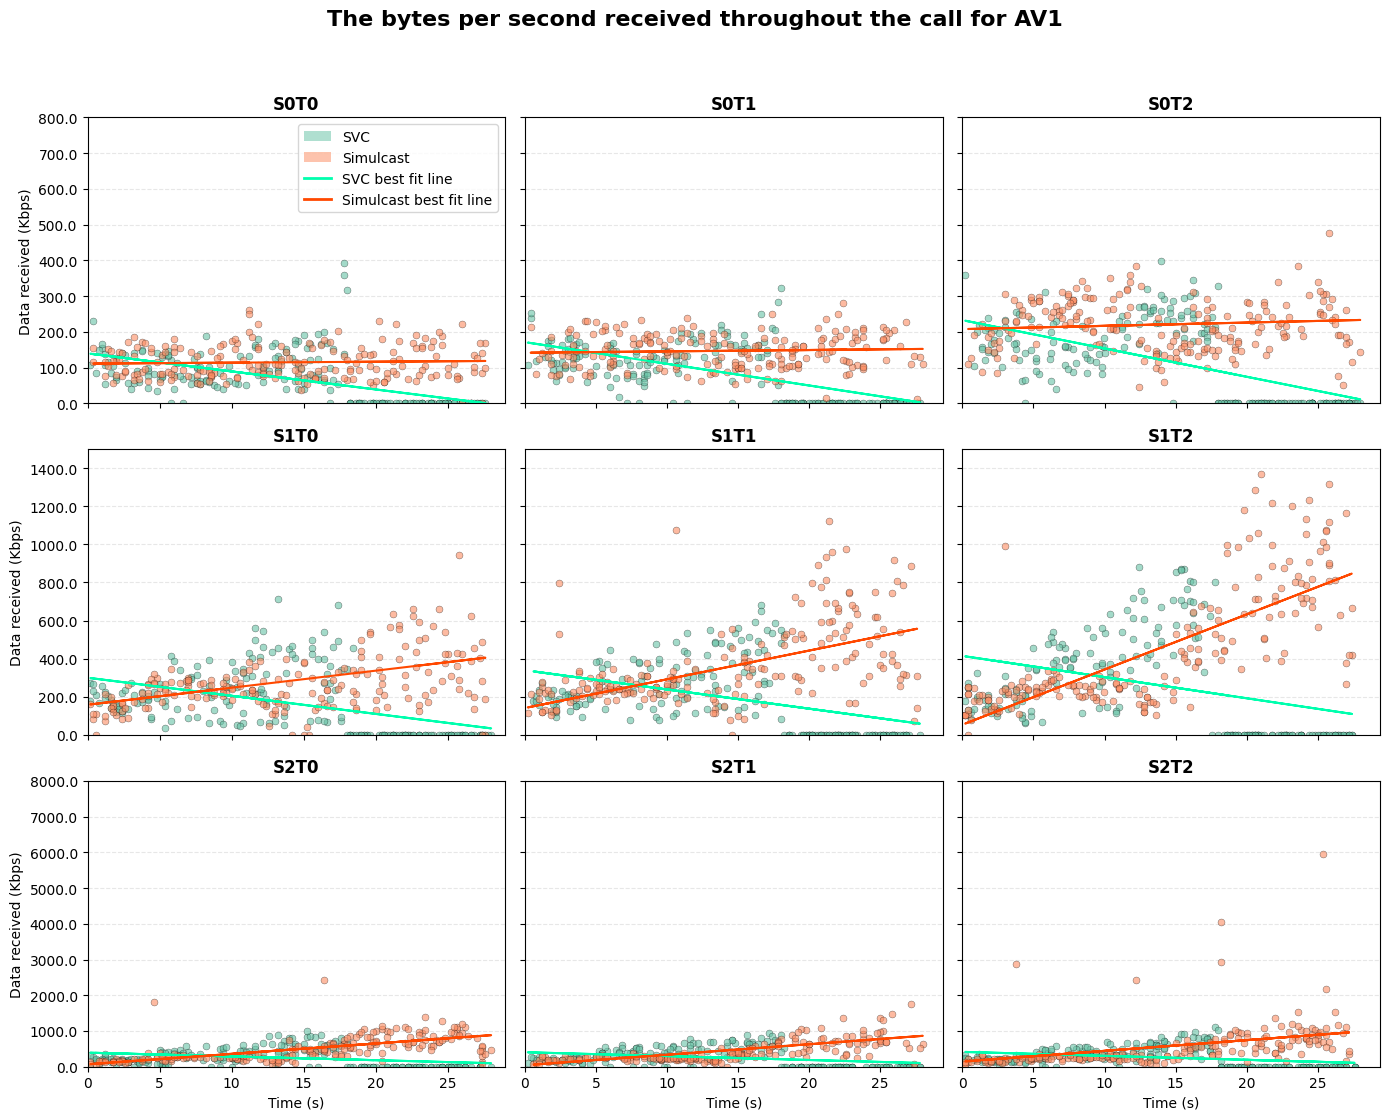

S0T0
S0T1
S0T2
S1T0
S1T1
S1T2
S2T0
S2T1
S2T2


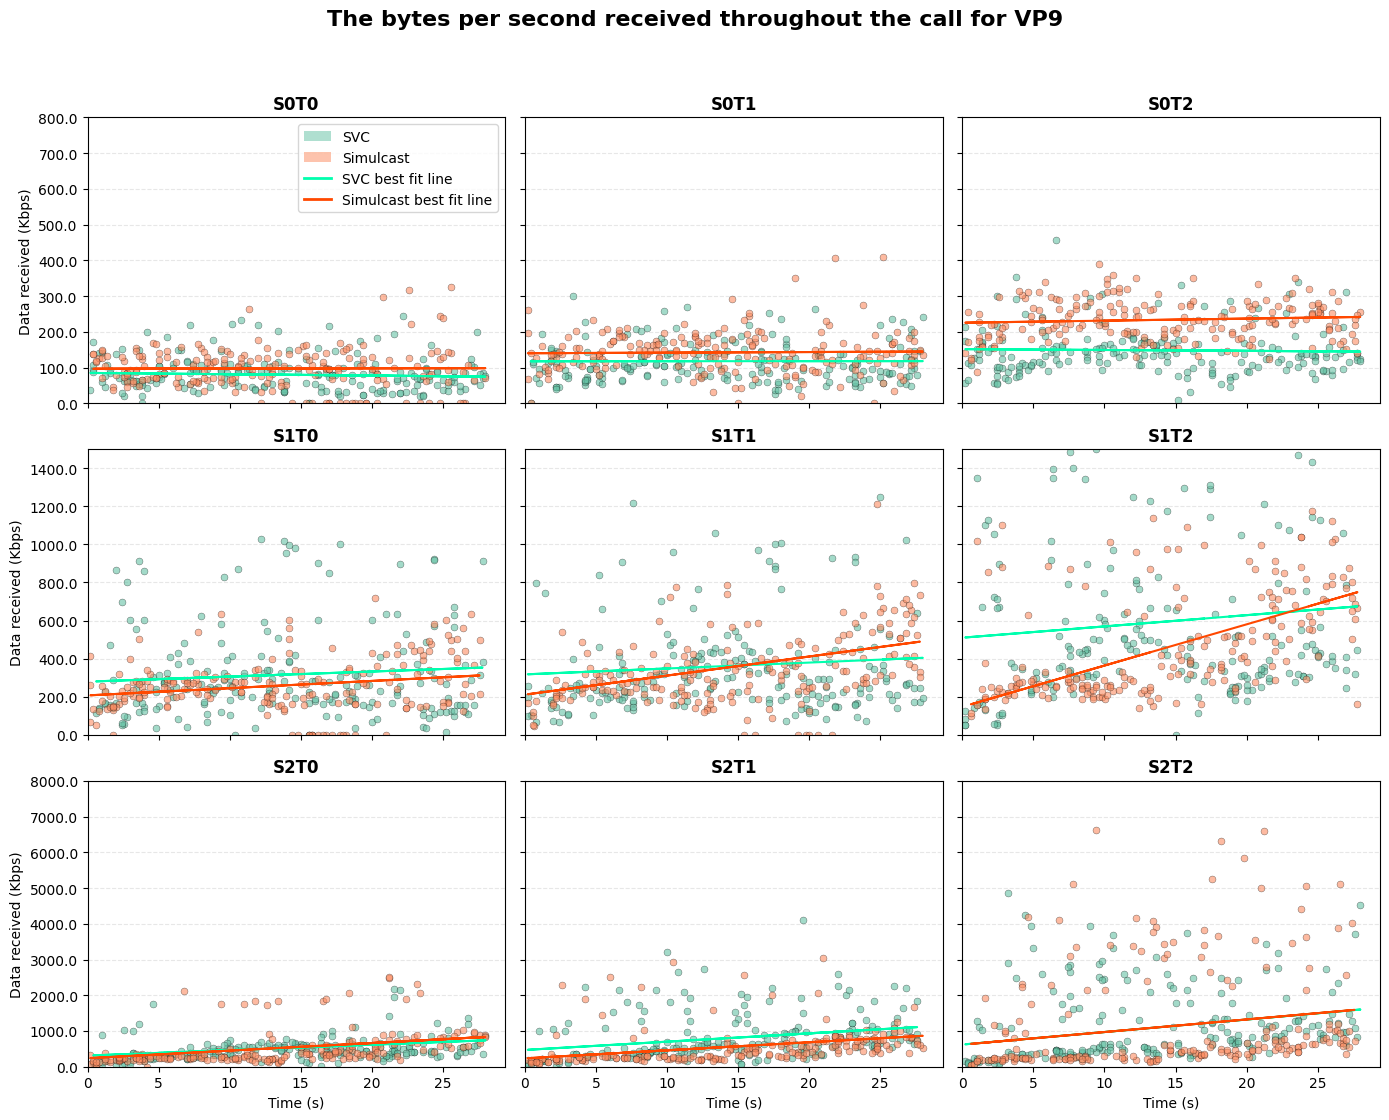

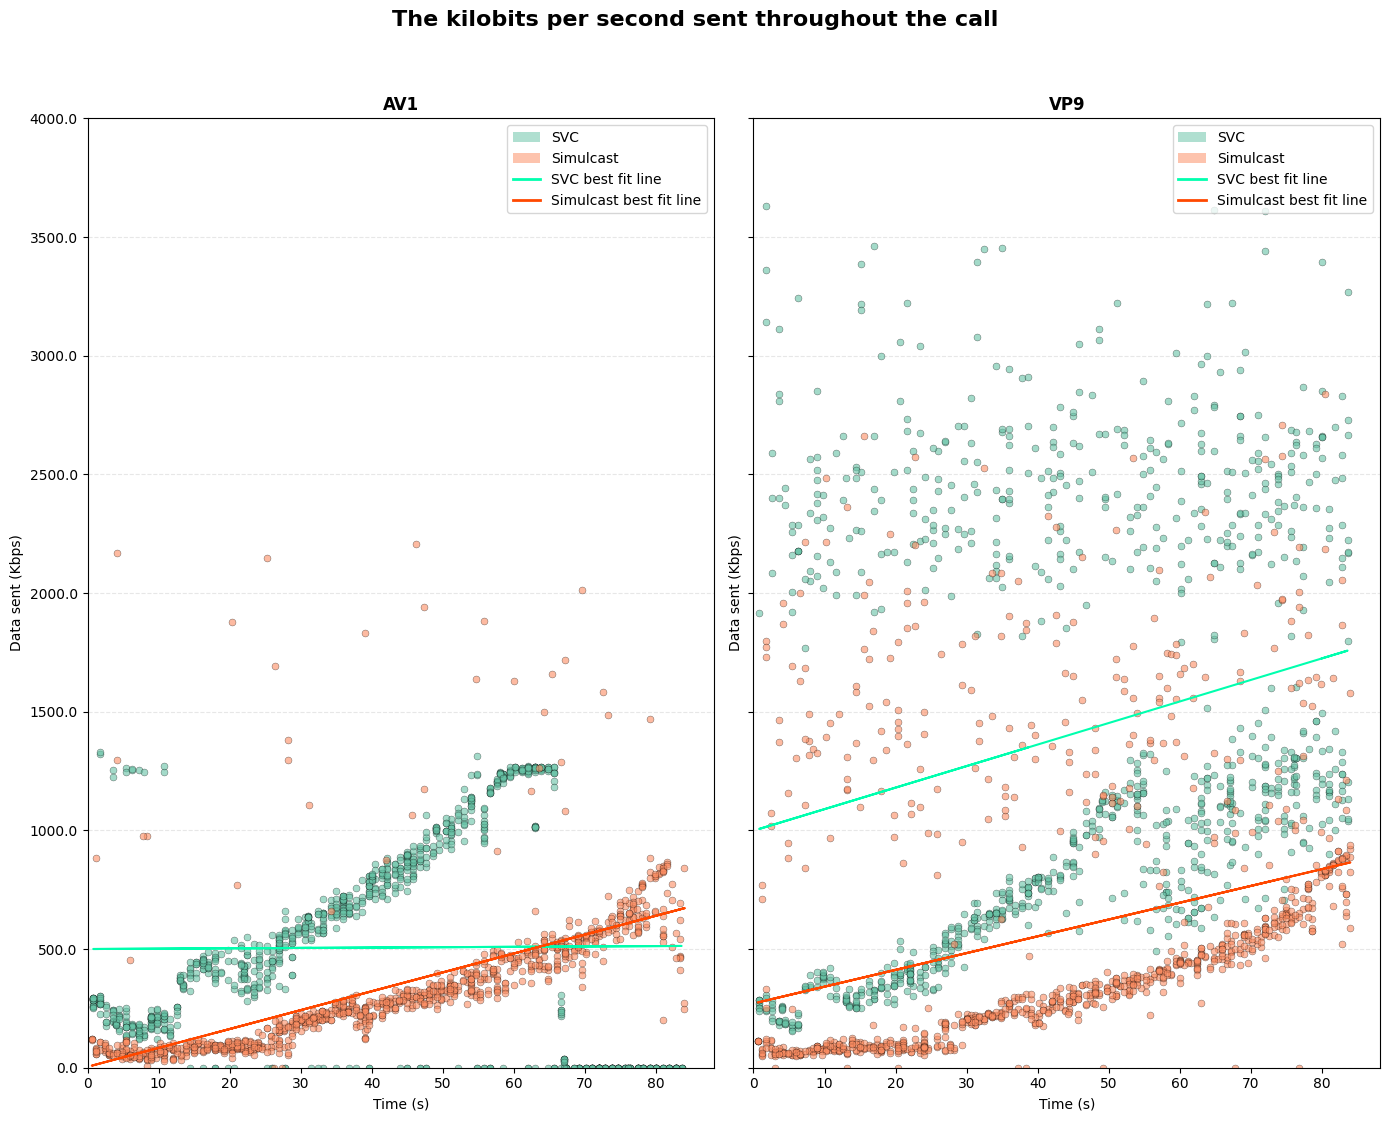

S0T0
S0T1
S0T2
S1T0
S1T1
S1T2
S2T0
S2T1
S2T2


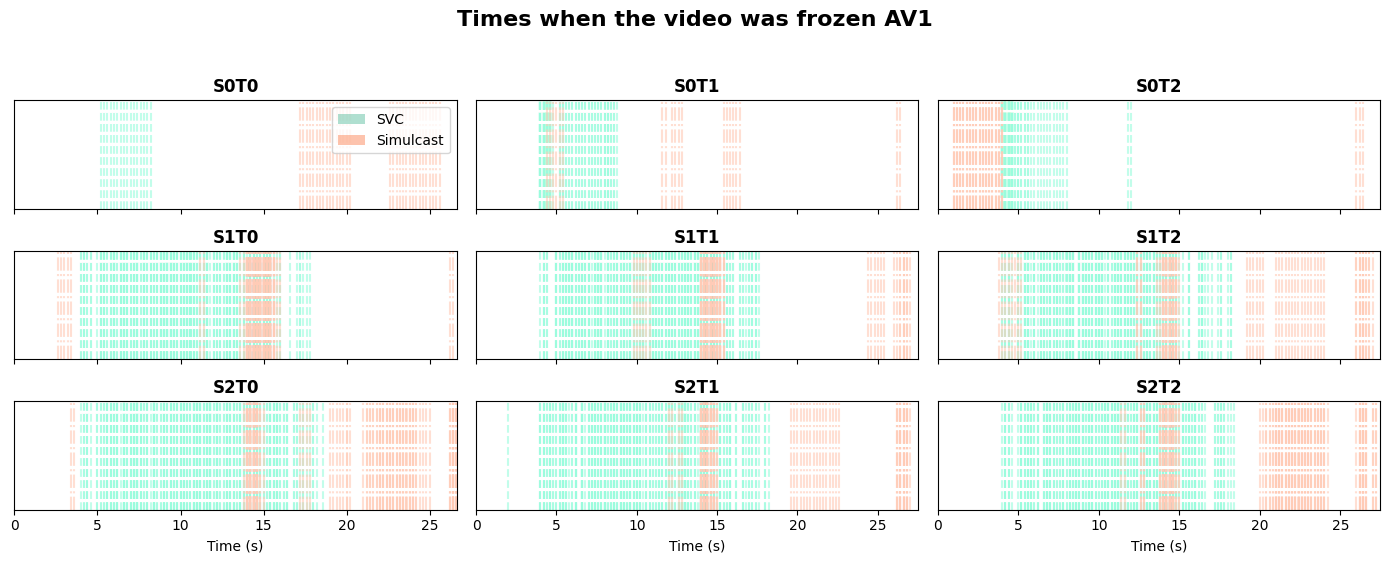

S0T0
S0T1
S0T2
S1T0
S1T1
S1T2
S2T0
S2T1
S2T2


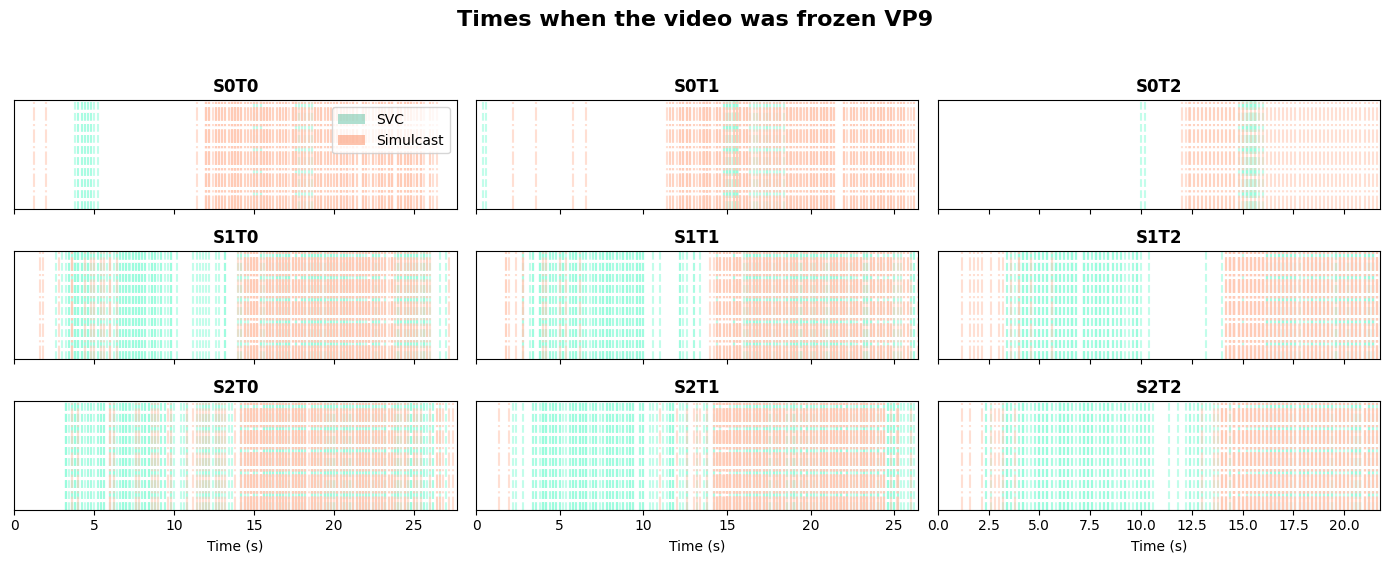

In [106]:
from typing import Optional, Self


class Data:
    dirs: list[Path]

    all_consumer_df: Optional[pd.DataFrame] = None
    all_producer_df: Optional[pd.DataFrame] = None
    consumer_totals_df: Optional[pd.DataFrame] = None
    producer_totals_df: Optional[pd.DataFrame] = None

    def __init__(self, dirs: list[Path]) -> None:
        self.dirs = dirs

    def _read_all(self, filename: str) -> pd.DataFrame:
        return pd.concat([pd.read_csv(d.joinpath(filename)) for d in self.dirs])

    def all_consumer(self):
        if self.all_consumer_df is None:
            self.all_consumer_df = self._read_all("all_consumer.csv")
        return self.all_consumer_df

    def all_producer(self):
        if self.all_producer_df is None:
            self.all_producer_df = self._read_all("all_producer.csv")
        return self.all_producer_df

    def consumer_totals(self):
        if self.consumer_totals_df is None:
            self.consumer_totals_df = self._read_all("consumer_total_bits.csv")
        return self.consumer_totals_df

    def producer_totals(self):
        if self.producer_totals_df is None:
            self.producer_totals_df = self._read_all("producer_total_bits.csv")
        return self.producer_totals_df

    def compare_codec(self, folder: Optional[Path] = None):
        add_save = lambda filename, config: config if folder == None else config.save_to(folder.joinpath(filename))

        producer_box_plots_per_codec(self.producer_totals(), add_save("producer_bytes.pdf", bytes_sent_config.with_title("Data sent by the producer per video codec").with_max(8)))
        producer_box_plots_per_codec(self.producer_totals(), add_save("producer_encode_time.pdf", encode_time_config.with_title("Total encode time in the producer per video codec")))

    def consumer_graphs(self, folder: Optional[Path] = None):
        add_save = lambda filename, config: config if folder == None else config.save_to(folder.joinpath(filename))

        df = self.consumer_totals()

        consumer_box_plots_per_codec(df, add_save("perc_per_codec.pdf", perc_config.with_max(100)))

        consumer_box_plots_per_codec(df, add_save("consumer_decode_time_per_codec.pdf", decode_time_config.with_title("Total decode time in the consumer per layer")))
        consumer_box_plots_per_codec(df, add_save("consumer_bytes_per_codec.pdf", bytes_recv_config.with_title("Data received by the consumer per layer")))

    def extra_performance_graphs(self, folder: Optional[Path] = None):
        add_save = lambda filename, config: config if folder == None else config.save_to(folder.joinpath(filename))

        consumer_box_plots_per_codec(self.consumer_totals(), add_save("freezes.pdf", freezes_config))
        consumer_box_plots_per_codec(self.consumer_totals(), add_save("consumer_processing_delay.pdf", total_processing_delay))
        producer_box_plots_per_codec(self.producer_totals(), add_save("producer_send_delay.pdf", total_packet_delay))

    def time_graph(self, folder: Optional[Path] = None):
        add_save = lambda filename, config: config if folder == None else config.save_to(folder.joinpath(filename))
        consumer = self.all_consumer()
        consumer_time_graph(consumer[consumer["codec"] == "video_av1"], add_save("all_consumer_time_av1.pdf", bps_recv_config.with_title("The bytes per second received throughout the call for AV1")))
        consumer_time_graph(consumer[consumer["codec"] == "video_vp9"], add_save("all_consumer_time_vp9.pdf", bps_recv_config.with_title("The bytes per second received throughout the call for VP9")))
        producer_time_graph(self.all_producer(), add_save("all_producer_time.pdf", bps_sent_config.with_max(4000)))
        consumer_frozen_graph(consumer[consumer["codec"] == "video_av1"], add_save("all_consumer_frozen_time_av1.pdf", frozen_lines_config.with_title("Times when the video was frozen AV1")))
        consumer_frozen_graph(consumer[consumer["codec"] == "video_vp9"], add_save("all_consumer_frozen_time_vp9.pdf", frozen_lines_config.with_title("Times when the video was frozen VP9")))

    def __add__(self, other: Self):
        return Data(self.dirs + other.dirs)

single_machine = Data([Path("single_machine")])
two_machine = Data([Path("two_machine")])
no_enc = Data([Path("single_no_enc")])
phone = Data([Path("phone")])

all_versions = single_machine + two_machine + no_enc + phone

all_enc = single_machine + two_machine + phone

# all_versions.compare_codec(Path("graphs/all"))
# all_versions.consumer_graphs(Path("graphs/all"))
# all_versions.extra_performance_graphs(Path("graphs/all"))

# all_enc.compare_codec(Path("graphs/all_enc"))
# all_enc.consumer_graphs(Path("graphs/all_enc"))
# all_enc.extra_performance_graphs(Path("graphs/all_enc"))

# no_enc.compare_codec(Path("graphs/no_enc"))
# no_enc.consumer_graphs(Path("graphs/no_enc"))
# no_enc.extra_performance_graphs(Path("graphs/no_enc"))

# single_machine.consumer_graphs(Path("graphs/single_machine"))
# two_machine.consumer_graphs(Path("graphs/two_machine"))
# phone.consumer_graphs(Path("graphs/phone"))

all_versions.time_graph(Path("graphs/all"))
